Starting rep 1


Simulating generations: 100%|██████████| 200/200 [01:22<00:00,  2.42it/s]


All done


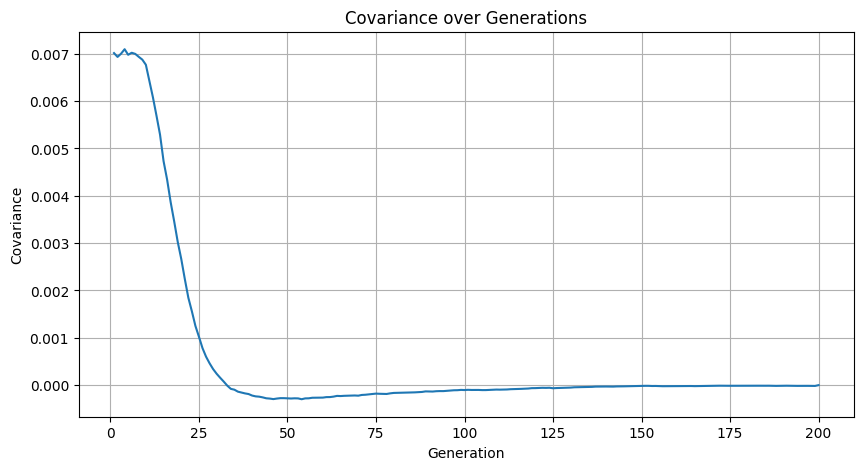

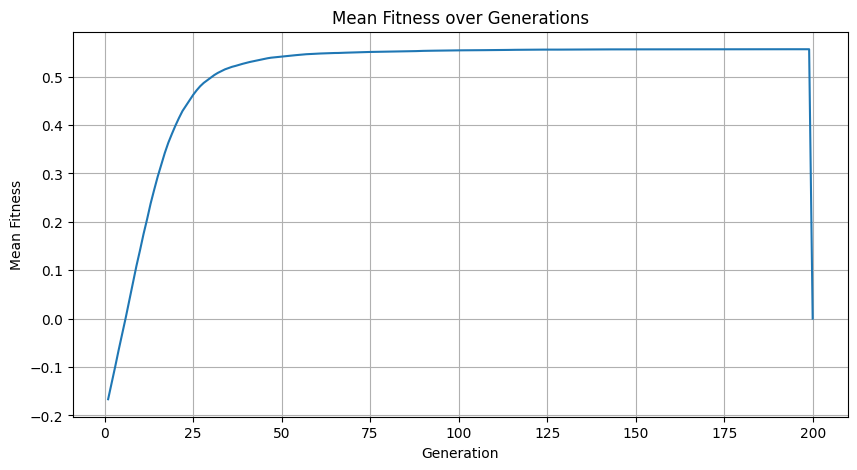

In [ ]:
# Here's a Python translation of the Julia code using NumPy, SciPy, and Matplotlib.
# It captures the same logic with array and loop transformations.

import numpy as np
from scipy.stats import multivariate_normal
from numpy.random import default_rng
import matplotlib.pyplot as plt

from tqdm import tqdm

rng = default_rng(seed=1234)

# Simulation parameters
N = int(2.7e4)
reps = 1
gens = 200
dj = 200
m = 1
U = np.exp(-3.0)

# Output containers
cv = [np.zeros(gens + 1) for _ in range(reps)]
mf = [np.zeros(gens + 1) for _ in range(reps)]
mfs = [np.full((gens + 1, gens + 1), np.nan) for _ in range(reps)]
mft = [np.full((gens + 1, gens + 1), np.nan) for _ in range(reps)]

# Bivariate normal distribution
mean = [-0.1, -0.1]
sdx = 0.1
sdy = 0.1
crxy = 0.7
cov = [[sdx**2, sdx * sdy * crxy], [sdx * sdy * crxy, sdy**2]]
dfe = multivariate_normal(mean=mean, cov=cov)

# Simulation
p0 = []
for i in range(reps):
    print(f"Starting rep {i+1}")

    p = rng.multivariate_normal(mean, cov, size=N)
    p0.append(p.copy())

    for j in tqdm(range(gens), desc="Simulating generations"):
        # if j % 25 == 0:
        #    print(f"generation {j}")

        px = p[:, 0].copy()
        py = p[:, 1].copy()

        px1 = px.copy()
        py1 = py.copy()

        fx = lambda t: np.sum(px1 * np.exp(px1 * t)) / np.sum(np.exp(px1 * t))
        fy = lambda t: np.sum(py1 * np.exp(py1 * t)) / np.sum(np.exp(py1 * t))

        for k in range(j, min(j + dj + 1, gens + 1)):
            dt = k - j
            mfs[i][j, k] = np.mean(px) + np.mean(py)

            if dt == m:
                px2 = px.copy()
                py2 = py.copy()
                fxy = lambda t: np.sum((px2 + py2) * np.exp((px2 + py2) * t)) / np.sum(np.exp((px2 + py2) * t))

            if dt <= m:
                mft[i][j, k] = fx(dt) + fy(dt)
            else:
                mft[i][j, k] = fxy(dt - m)

            if dt <= m:
                wx = np.exp(px)
                wy = np.exp(py)
                wx /= wx.sum()
                wy /= wy.sum()
                ngx = rng.choice(N, size=N, p=wx)
                ngy = rng.choice(N, size=N, p=wy)
            else:
                wxy = np.exp(px + py)
                wxy /= wxy.sum()
                ngxy = rng.choice(N, size=N, p=wxy)
                ngx = ngxy
                ngy = ngxy

            px = px[ngx]
            py = py[ngy]

        cv[i][j] = np.cov(p[:, 0], p[:, 1])[0, 1]
        mf[i][j] = np.mean(p[:, 0] + p[:, 1])

        ww = np.exp(p[:, 0] + p[:, 1])
        ww /= ww.sum()
        next_gen = rng.choice(N, size=N, p=ww)

        p = p[next_gen, :]

print("All done")


# Plot
plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, gens + 1), cv[0][1:])  # x has length 500
plt.title("Covariance over Generations")
plt.xlabel("Generation")
plt.ylabel("Covariance")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(range(1, gens + 1), mf[0][1:])
plt.title("Mean Fitness over Generations")
plt.xlabel("Generation")
plt.ylabel("Mean Fitness")
plt.grid(True)
plt.show()


In [ ]:
print("gens =", gens)
print("np.arange(1, gens).shape =", np.arange(1, gens).shape)
print("cv[0].shape =", np.shape(cv[0]))
print("cv[0][1:].shape =", np.shape(cv[0][1:]))


gens = 500
np.arange(1, gens).shape = (499,)
cv[0].shape = (501,)
cv[0][1:].shape = (500,)


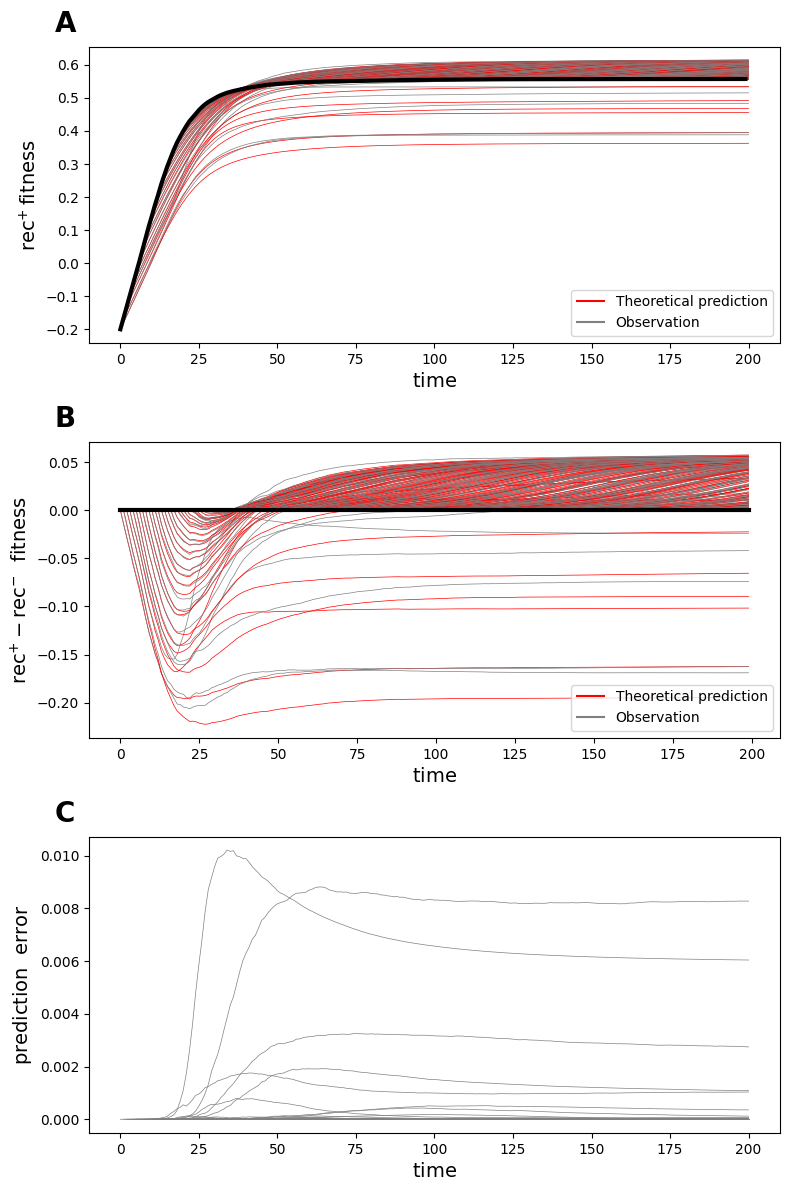

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Set up plot size and font
fig, axs = plt.subplots(3, 1, figsize=(8, 12))  # 8 inches x 12 inches total (3 plots of 4 inches tall)

# Plot A
ax = axs[0]
for i in range(gens):
    ax.plot(mft[0][i, :], color='red', linewidth=0.5)
    ax.plot(mfs[0][i, :], color='gray', linewidth=0.5)
ax.plot(mf[0][:-1], color='black', linewidth=3)

# Add dummy lines to make legend entries
ax.plot(np.arange(100), [np.nan]*100, color='red', label='Theoretical prediction')
ax.plot(np.arange(100), [np.nan]*100, color='gray', label='Observation')

ax.set_xlabel(r"$\mathrm{time}$", fontsize=14)
ax.set_ylabel(r"$\mathrm{rec}^{+} \, \mathrm{fitness}$", fontsize=14)
ax.legend(loc='lower right')
ax.text(-0.05, 1.05, 'A', transform=ax.transAxes, fontsize=20, fontweight='bold')
ax.set_frame_on(True)

# Plot B
ax = axs[1]
for i in range(gens):
    ax.plot(mft[0][i, :][:-1] - mf[0][:-1], color='red', linewidth=0.5)
    ax.plot(mfs[0][i, :][:-1] - mf[0][:-1], color='gray', linewidth=0.5)
ax.plot(np.zeros_like(mf[0][:-1]), color='black', linewidth=3)

ax.plot(np.arange(100), [np.nan]*100, color='red', label='Theoretical prediction')
ax.plot(np.arange(100), [np.nan]*100, color='gray', label='Observation')

ax.set_xlabel(r"$\mathrm{time}$", fontsize=14)
ax.set_ylabel(r"$\mathrm{rec}^{+} - \mathrm{rec}^{-} ~~ \mathrm{fitness}$", fontsize=14)
ax.legend(loc='lower right')
ax.text(-0.05, 1.05, 'B', transform=ax.transAxes, fontsize=20, fontweight='bold')
ax.set_frame_on(True)

# Plot C
ax = axs[2]
for i in range(gens):
    ax.plot((mft[0][i, :] - mfs[0][i, :])**2, color='gray', linewidth=0.5)
ax.set_xlabel(r"$\mathrm{time}$", fontsize=14)
ax.set_ylabel(r"$\mathrm{prediction ~~ error}$", fontsize=14)
ax.text(-0.05, 1.05, 'C', transform=ax.transAxes, fontsize=20, fontweight='bold')
ax.set_frame_on(True)

plt.tight_layout()
plt.show()


In [1]:
mfs[0]

UndefVarError: UndefVarError: `mfs` not defined